In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Fixed version for your actual data structure
# Your masks are stored as: masks/image_name/oc.png and masks/image_name/od.png

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# FIXED DATA ANALYZER FOR YOUR ACTUAL STRUCTURE
# =============================================================================

class FixedDataAnalyzer:
    def __init__(self, csv_path, images_dir, masks_dir):
        self.csv_path = Path(csv_path)
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.df = None

    def load_and_analyze_csv(self):
        """CSV file analysis with proper column detection"""
        print("=== CSV Label Analysis ===")
        self.df = pd.read_csv(self.csv_path)
        print(f"CSV shape: {self.df.shape}")
        print(f"Columns: {list(self.df.columns)}")
        print(f"\nFirst 5 rows:")
        print(self.df.head())

        # For your specific case: first column is image names, second is labels
        print(f"\nDetected structure:")
        print(f"  Image column: '{self.df.columns[0]}' (contains filenames)")
        print(f"  Label column: '{self.df.columns[1]}' (contains 0/1 labels)")

        # Show label distribution
        label_col = self.df.columns[1]
        print(f"\nLabel distribution:")
        print(self.df[label_col].value_counts().sort_index())

        return self.df

    def analyze_file_structure(self):
        """Analyze your actual file structure"""
        print("\n=== File Structure Analysis ===")

        # Images analysis
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
        image_files = []
        for ext in image_extensions:
            image_files.extend(list(self.images_dir.glob(f"*{ext}")))
            image_files.extend(list(self.images_dir.glob(f"*{ext.upper()}")))

        print(f"Images directory: {self.images_dir}")
        print(f"Total image files found: {len(image_files)}")

        if image_files:
            sample_img = image_files[0]
            print(f"Sample image: {sample_img.name}")
            img = cv2.imread(str(sample_img))
            if img is not None:
                print(f"Image shape: {img.shape}")

        # Masks analysis - Your actual structure
        print(f"\nMasks directory: {self.masks_dir}")

        mask_folders = [d for d in self.masks_dir.iterdir() if d.is_dir()]
        print(f"Mask folders found: {len(mask_folders)}")

        if mask_folders:
            sample_folder = mask_folders[0]
            print(f"Sample mask folder: {sample_folder.name}")

            # Check for direct oc.png and od.png files
            oc_file = sample_folder / "oc.png"
            od_file = sample_folder / "od.png"

            print(f"  Structure: Direct files in folder")
            print(f"  OC file exists: {oc_file.exists()}")
            print(f"  OD file exists: {od_file.exists()}")

            if oc_file.exists():
                oc_mask = cv2.imread(str(oc_file), 0)
                if oc_mask is not None:
                    print(f"  OC mask shape: {oc_mask.shape}")
                    print(f"  OC unique values: {np.unique(oc_mask)}")

            if od_file.exists():
                od_mask = cv2.imread(str(od_file), 0)
                if od_mask is not None:
                    print(f"  OD mask shape: {od_mask.shape}")
                    print(f"  OD unique values: {np.unique(od_mask)}")

        return image_files, mask_folders

    def validate_data_consistency(self, image_files, mask_folders):
        """Check consistency with your actual structure"""
        print("\n=== Data Consistency Check ===")

        if self.df is None:
            print("Please load CSV first!")
            return None

        # Get filenames from CSV
        image_col = self.df.columns[0]
        csv_names = set(self.df[image_col].astype(str))

        # Remove extensions to get stems
        csv_stems = set([name.replace('.png', '').replace('.jpg', '').replace('.jpeg', '')
                        for name in csv_names])

        image_names = set([f.stem for f in image_files])
        mask_folder_names = set([f.name for f in mask_folders])

        print(f"CSV entries: {len(csv_names)}")
        print(f"Image files: {len(image_names)}")
        print(f"Mask folders: {len(mask_folder_names)}")

        # Check for valid combinations
        valid_samples = set()
        issues = []

        for csv_name in list(csv_names)[:10]:  # Check first 10 for debugging
            csv_stem = csv_name.replace('.png', '').replace('.jpg', '').replace('.jpeg', '')

            # Check if image exists
            image_exists = csv_stem in image_names

            # Check if mask folder exists
            mask_folder_exists = csv_stem in mask_folder_names

            if image_exists and mask_folder_exists:
                # Check if oc.png and od.png exist in mask folder
                mask_folder_path = self.masks_dir / csv_stem
                oc_file = mask_folder_path / "oc.png"
                od_file = mask_folder_path / "od.png"

                if oc_file.exists() and od_file.exists():
                    valid_samples.add(csv_stem)
                else:
                    missing = []
                    if not oc_file.exists():
                        missing.append("oc.png")
                    if not od_file.exists():
                        missing.append("od.png")
                    issues.append(f"{csv_stem}: Missing {', '.join(missing)}")
            else:
                missing = []
                if not image_exists:
                    missing.append("image")
                if not mask_folder_exists:
                    missing.append("mask folder")
                issues.append(f"{csv_stem}: Missing {', '.join(missing)}")

        print(f"\n📊 Summary:")
        print(f"Valid samples (with image + oc.png + od.png): {len(valid_samples)}")

        if len(issues) > 0 and len(issues) <= 10:
            print(f"\n⚠️ Issues found:")
            for issue in issues:
                print(f"  - {issue}")
        elif len(issues) > 10:
            print(f"\n⚠️ Issues found ({len(issues)} total, showing first 5):")
            for issue in issues[:5]:
                print(f"  - {issue}")

        return valid_samples

# =============================================================================
# FIXED DATASET CLASS FOR YOUR STRUCTURE
# =============================================================================

class FixedFundusDataset(Dataset):
    def __init__(self, csv_path, images_dir, masks_dir, transform=None, mode='train'):
        self.csv_path = Path(csv_path)
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.transform = transform
        self.mode = mode

        # Load CSV
        self.df = pd.read_csv(csv_path)

        # For your specific CSV structure
        self.image_col = self.df.columns[0]  # First column contains image names
        self.label_col = self.df.columns[1]  # Second column contains labels

        print(f"Using image column: '{self.image_col}'")
        print(f"Using label column: '{self.label_col}'")

        # Filter valid samples
        self.valid_indices = self._find_valid_samples()
        print(f"Valid samples: {len(self.valid_indices)}")

    def _find_valid_samples(self):
        """Find samples that have both image and mask files"""
        valid_indices = []

        for idx, row in self.df.iterrows():
            image_name = str(row[self.image_col])

            # Remove extension to get folder name
            image_stem = image_name.replace('.png', '').replace('.jpg', '').replace('.jpeg', '')

            # Check if image file exists
            image_path = None
            for ext in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']:
                img_file = self.images_dir / f"{image_stem}{ext}"
                if img_file.exists():
                    image_path = img_file
                    break

            # Check if mask folder exists with oc.png and od.png
            mask_folder = self.masks_dir / image_stem
            oc_file = mask_folder / "oc.png"
            od_file = mask_folder / "od.png"

            if (image_path and mask_folder.exists() and
                oc_file.exists() and od_file.exists()):
                valid_indices.append(idx)

        return valid_indices

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        row = self.df.iloc[actual_idx]

        image_name = str(row[self.image_col])
        label = row[self.label_col]

        # Remove extension to get base name
        image_stem = image_name.replace('.png', '').replace('.jpg', '').replace('.jpeg', '')

        # Load image
        image_path = None
        for ext in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']:
            img_file = self.images_dir / f"{image_stem}{ext}"
            if img_file.exists():
                image_path = img_file
                break

        if not image_path:
            raise FileNotFoundError(f"Image not found for {image_name}")

        # Load masks directly from folder (your actual structure)
        mask_folder = self.masks_dir / image_stem
        oc_file = mask_folder / "oc.png"
        od_file = mask_folder / "od.png"

        # Load files
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        oc_mask = cv2.imread(str(oc_file), 0)
        od_mask = cv2.imread(str(od_file), 0)

        # Create combined mask (Background=0, OD=1, OC=2)
        combined_mask = np.zeros_like(oc_mask)
        combined_mask[od_mask > 128] = 1  # OD region
        combined_mask[oc_mask > 128] = 2  # OC region (overwrites OD where they overlap)

        # Convert label to appropriate format
        if isinstance(label, str):
            label = 1 if label.lower() in ['glaucoma', 'positive', '1', 'true'] else 0
        else:
            label = int(float(label))

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=combined_mask)
            image = augmented['image']
            combined_mask = augmented['mask']

        # Fix data type issue - convert to long tensor properly
        if isinstance(combined_mask, np.ndarray):
            combined_mask = torch.from_numpy(combined_mask.astype(np.int64))
        else:
            combined_mask = combined_mask.long()

        return {
            'image': image,
            'mask': combined_mask,
            'label': torch.FloatTensor([label]),
            'image_name': image_name
        }

# =============================================================================
# FIXED SETUP FUNCTION
# =============================================================================

def setup_fixed_pipeline(csv_path, images_dir, masks_dir):
    """Setup pipeline for your actual data structure"""

    print("🚀 Fixed Custom Fundus Analysis Pipeline")
    print("=" * 50)

    # Step 1: Analyze your data with fixed analyzer
    print("\n📊 Step 1: Data Analysis")
    analyzer = FixedDataAnalyzer(csv_path, images_dir, masks_dir)

    # Load and analyze CSV
    df = analyzer.load_and_analyze_csv()

    # Analyze file structure
    image_files, mask_folders = analyzer.analyze_file_structure()

    # Validate consistency
    valid_samples = analyzer.validate_data_consistency(image_files, mask_folders)

    # Step 2: Create dataset with fixed class
    print(f"\n📦 Step 2: Dataset Creation")

    # Create transforms
    train_transform = A.Compose([
        A.Resize(512, 512),
        A.Rotate(limit=15, p=0.7),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
        A.HorizontalFlip(p=0.5),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

    val_transform = A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

    # Create dataset with fixed class
    full_dataset = FixedFundusDataset(
        csv_path=csv_path,
        images_dir=images_dir,
        masks_dir=masks_dir,
        transform=val_transform
    )

    if len(full_dataset) == 0:
        print("❌ No valid samples found! Check your file structure.")
        return None

    # Split dataset
    train_indices, temp_indices = train_test_split(
        range(len(full_dataset)), test_size=0.3, random_state=42
    )
    val_indices, test_indices = train_test_split(
        temp_indices, test_size=0.5, random_state=42
    )

    print(f"Dataset splits:")
    print(f"  Training: {len(train_indices)} samples")
    print(f"  Validation: {len(val_indices)} samples")
    print(f"  Testing: {len(test_indices)} samples")

    # Step 3: Model setup (using your existing model)
    print("\n🏗️ Step 3: Model Setup")

    # For your data: 3 classes (background=0, OD=1, OC=2)
    num_seg_classes = 3
    num_cls_classes = 1  # Binary classification

    print(f"Segmentation classes: {num_seg_classes} (Background, OD, OC)")
    print(f"Classification: Binary (Glaucoma/Normal)")

    # You can use your existing CustomFundusModel here
    # model = CustomFundusModel(num_classes_seg=num_seg_classes, num_classes_cls=num_cls_classes)

    print("✅ Fixed pipeline setup complete!")

    return {
        'dataset': full_dataset,
        'train_indices': train_indices,
        'val_indices': val_indices,
        'test_indices': test_indices,
        'transforms': (train_transform, val_transform),
        'data_info': {
            'total_samples': len(full_dataset),
            'num_seg_classes': num_seg_classes,
            'num_cls_classes': num_cls_classes,
            'valid_samples': valid_samples
        }
    }

# =============================================================================
# EXAMPLE USAGE WITH YOUR PATHS
# =============================================================================

if __name__ == "__main__":
    # Your actual paths
    CSV_PATH = "/content/drive/MyDrive/Training/dristi_labels.csv"
    IMAGES_DIR = "/content/drive/MyDrive/Training/Images"
    MASKS_DIR = "/content/drive/MyDrive/Training/masks"

    # Setup fixed pipeline
    pipeline = setup_fixed_pipeline(
        csv_path=CSV_PATH,
        images_dir=IMAGES_DIR,
        masks_dir=MASKS_DIR
    )

    if pipeline:
        print("\n🎯 Ready to start training!")
        print("Next steps:")
        print("1. Use pipeline['dataset'] for your data")
        print("2. Create your model with 3 segmentation classes")
        print("3. Start training loop")
        print("4. Create separate testing model for validation")
    else:
        print("❌ Pipeline setup failed!")

🚀 Fixed Custom Fundus Analysis Pipeline

📊 Step 1: Data Analysis
=== CSV Label Analysis ===
CSV shape: (100, 2)
Columns: ['drishtiGS_001.png', '1']

First 5 rows:
   drishtiGS_001.png  1
0  drishtiGS_002.png  1
1  drishtiGS_003.png  1
2  drishtiGS_004.png  1
3  drishtiGS_005.png  1
4  drishtiGS_006.png  1

Detected structure:
  Image column: 'drishtiGS_001.png' (contains filenames)
  Label column: '1' (contains 0/1 labels)

Label distribution:
1
0    31
1    69
Name: count, dtype: int64

=== File Structure Analysis ===
Images directory: /content/drive/MyDrive/Training/Images
Total image files found: 101
Sample image: drishtiGS_002.png
Image shape: (1752, 2045, 3)

Masks directory: /content/drive/MyDrive/Training/masks
Mask folders found: 101
Sample mask folder: drishtiGS_092
  Structure: Direct files in folder
  OC file exists: True
  OD file exists: True
  OC mask shape: (1749, 2050)
  OC unique values: [  0  64 128 191 255]
  OD mask shape: (1749, 2050)
  OD unique values: [  0  64 1

In [ ]:
# =============================================================================
# GOOGLE COLAB CELL 2: TRAINING SCRIPT
# Copy paste this entire code in your 2nd cell
# =============================================================================

# Complete Training Script for Fundus Analysis
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import os

print("🚀 Training Script Loaded Successfully!")

# =============================================================================
# TRAINING UTILITIES
# =============================================================================

class TrainingLogger:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.train_seg_losses = []
        self.train_cls_losses = []
        self.val_seg_losses = []
        self.val_cls_losses = []
        self.train_acc = []
        self.val_acc = []
        self.train_dice = []
        self.val_dice = []

    def log_epoch(self, train_metrics, val_metrics):
        # Training metrics
        self.train_losses.append(train_metrics['total_loss'])
        self.train_seg_losses.append(train_metrics['seg_loss'])
        self.train_cls_losses.append(train_metrics['cls_loss'])
        self.train_acc.append(train_metrics['accuracy'])
        self.train_dice.append(train_metrics['dice'])

        # Validation metrics
        self.val_losses.append(val_metrics['total_loss'])
        self.val_seg_losses.append(val_metrics['seg_loss'])
        self.val_cls_losses.append(val_metrics['cls_loss'])
        self.val_acc.append(val_metrics['accuracy'])
        self.val_dice.append(val_metrics['dice'])

    def plot_training_curves(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        # Total Loss
        axes[0,0].plot(self.train_losses, label='Train', color='blue', linewidth=2)
        axes[0,0].plot(self.val_losses, label='Validation', color='red', linewidth=2)
        axes[0,0].set_title('Total Loss', fontsize=14, fontweight='bold')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)

        # Segmentation Loss
        axes[0,1].plot(self.train_seg_losses, label='Train Seg', color='green', linewidth=2)
        axes[0,1].plot(self.val_seg_losses, label='Val Seg', color='orange', linewidth=2)
        axes[0,1].set_title('Segmentation Loss', fontsize=14, fontweight='bold')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)

        # Classification Loss
        axes[0,2].plot(self.train_cls_losses, label='Train Cls', color='purple', linewidth=2)
        axes[0,2].plot(self.val_cls_losses, label='Val Cls', color='brown', linewidth=2)
        axes[0,2].set_title('Classification Loss', fontsize=14, fontweight='bold')
        axes[0,2].legend()
        axes[0,2].grid(True, alpha=0.3)

        # Accuracy
        axes[1,0].plot(self.train_acc, label='Train Acc', color='blue', linewidth=2)
        axes[1,0].plot(self.val_acc, label='Val Acc', color='red', linewidth=2)
        axes[1,0].set_title('Classification Accuracy', fontsize=14, fontweight='bold')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        axes[1,0].set_ylim(0, 1)

        # Dice Score
        axes[1,1].plot(self.train_dice, label='Train Dice', color='green', linewidth=2)
        axes[1,1].plot(self.val_dice, label='Val Dice', color='orange', linewidth=2)
        axes[1,1].set_title('Segmentation Dice Score', fontsize=14, fontweight='bold')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        axes[1,1].set_ylim(0, 1)

        # Final Results Summary
        if len(self.val_losses) > 0:
            best_val_loss = min(self.val_losses)
            best_dice = max(self.val_dice)
            best_acc = max(self.val_acc)

            axes[1,2].text(0.5, 0.7, f'🏆 BEST RESULTS', ha='center', va='center',
                          fontsize=16, fontweight='bold', color='green')
            axes[1,2].text(0.5, 0.5, f'Val Loss: {best_val_loss:.4f}', ha='center', va='center', fontsize=12)
            axes[1,2].text(0.5, 0.4, f'Dice Score: {best_dice:.4f}', ha='center', va='center', fontsize=12)
            axes[1,2].text(0.5, 0.3, f'Accuracy: {best_acc:.4f}', ha='center', va='center', fontsize=12)
        else:
            axes[1,2].text(0.5, 0.5, 'Training\nStarting...', ha='center', va='center', fontsize=16)

        axes[1,2].set_title('Training Summary', fontsize=14, fontweight='bold')
        axes[1,2].set_xlim(0, 1)
        axes[1,2].set_ylim(0, 1)
        axes[1,2].axis('off')

        plt.tight_layout()
        plt.show()

def calculate_dice_score(pred_mask, true_mask, num_classes=3):
    """Calculate Dice coefficient for each class"""
    pred_mask = torch.argmax(pred_mask, dim=1)
    dice_scores = []

    for class_id in range(1, num_classes):  # Skip background (0)
        pred_binary = (pred_mask == class_id).float()
        true_binary = (true_mask == class_id).float()

        intersection = (pred_binary * true_binary).sum()
        union = pred_binary.sum() + true_binary.sum()

        if union == 0:
            dice = 1.0  # Perfect score if both are empty
        else:
            dice = (2. * intersection) / (union + 1e-8)

        dice_scores.append(dice.item())

    return np.mean(dice_scores) if dice_scores else 0.0

def calculate_classification_metrics(predictions, targets):
    """Calculate classification metrics"""
    # Convert to numpy
    predictions = torch.sigmoid(predictions).cpu().numpy()
    targets = targets.cpu().numpy()

    # Binary predictions
    pred_binary = (predictions > 0.5).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(targets, pred_binary)
    precision, recall, f1, _ = precision_recall_fscore_support(
        targets, pred_binary, average='binary', zero_division=0
    )

    try:
        auc = roc_auc_score(targets, predictions)
    except:
        auc = 0.0

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }

# =============================================================================
# IMPROVED COMBINED LOSS
# =============================================================================

class ImprovedCombinedLoss(nn.Module):
    def __init__(self, seg_weight=2.0, cls_weight=1.0, focal_alpha=0.25, focal_gamma=2.0):
        super().__init__()
        self.seg_weight = seg_weight
        self.cls_weight = cls_weight

        # Weighted CrossEntropy for segmentation (background class gets less weight)
        self.seg_loss = nn.CrossEntropyLoss()

        # Focal Loss parameters
        self.cls_loss = nn.BCEWithLogitsLoss()
        self.focal_alpha = focal_alpha
        self.focal_gamma = focal_gamma

    def focal_loss(self, inputs, targets):
        """Focal loss implementation for handling class imbalance"""
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.focal_alpha * (1-pt)**self.focal_gamma * bce_loss
        return focal_loss.mean()

    def forward(self, outputs, targets):
        seg_loss = self.seg_loss(outputs['segmentation'], targets['mask'])
        cls_loss = self.focal_loss(outputs['classification'], targets['label'])

        total_loss = self.seg_weight * seg_loss + self.cls_weight * cls_loss

        return {
            'total_loss': total_loss,
            'seg_loss': seg_loss,
            'cls_loss': cls_loss
        }

# =============================================================================
# TRAINING AND VALIDATION FUNCTIONS
# =============================================================================

def train_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()

    total_loss = 0
    total_seg_loss = 0
    total_cls_loss = 0
    all_predictions = []
    all_targets = []
    all_dice_scores = []

    progress_bar = tqdm(dataloader, desc=f'🔥 Training Epoch {epoch+1}',
                       ncols=100, bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

    for batch_idx, batch in enumerate(progress_bar):
        # Move to device
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)
        labels = batch['label'].to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)

        # Calculate loss
        targets = {'mask': masks, 'label': labels}
        loss_dict = criterion(outputs, targets)

        # Backward pass
        loss_dict['total_loss'].backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Accumulate metrics
        total_loss += loss_dict['total_loss'].item()
        total_seg_loss += loss_dict['seg_loss'].item()
        total_cls_loss += loss_dict['cls_loss'].item()

        # Calculate Dice score
        dice_score = calculate_dice_score(outputs['segmentation'], masks)
        all_dice_scores.append(dice_score)

        # Store predictions for accuracy calculation
        all_predictions.extend(outputs['classification'].detach())
        all_targets.extend(labels.detach())

        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{loss_dict["total_loss"].item():.4f}',
            'Dice': f'{dice_score:.3f}'
        })

    # Calculate epoch metrics
    avg_loss = total_loss / len(dataloader)
    avg_seg_loss = total_seg_loss / len(dataloader)
    avg_cls_loss = total_cls_loss / len(dataloader)
    avg_dice = np.mean(all_dice_scores)

    # Calculate classification accuracy
    all_predictions = torch.stack(all_predictions)
    all_targets = torch.stack(all_targets)
    cls_metrics = calculate_classification_metrics(all_predictions, all_targets)

    return {
        'total_loss': avg_loss,
        'seg_loss': avg_seg_loss,
        'cls_loss': avg_cls_loss,
        'dice': avg_dice,
        'accuracy': cls_metrics['accuracy'],
        'precision': cls_metrics['precision'],
        'recall': cls_metrics['recall'],
        'f1': cls_metrics['f1'],
        'auc': cls_metrics['auc']
    }

def validate_epoch(model, dataloader, criterion, device, epoch):
    model.eval()

    total_loss = 0
    total_seg_loss = 0
    total_cls_loss = 0
    all_predictions = []
    all_targets = []
    all_dice_scores = []

    progress_bar = tqdm(dataloader, desc=f'✅ Validation Epoch {epoch+1}',
                       ncols=100, bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]')

    with torch.no_grad():
        for batch in progress_bar:
            # Move to device
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            labels = batch['label'].to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            targets = {'mask': masks, 'label': labels}
            loss_dict = criterion(outputs, targets)

            # Accumulate metrics
            total_loss += loss_dict['total_loss'].item()
            total_seg_loss += loss_dict['seg_loss'].item()
            total_cls_loss += loss_dict['cls_loss'].item()

            # Calculate Dice score
            dice_score = calculate_dice_score(outputs['segmentation'], masks)
            all_dice_scores.append(dice_score)

            # Store predictions
            all_predictions.extend(outputs['classification'].detach())
            all_targets.extend(labels.detach())

            progress_bar.set_postfix({
                'Loss': f'{loss_dict["total_loss"].item():.4f}',
                'Dice': f'{dice_score:.3f}'
            })

    # Calculate epoch metrics
    avg_loss = total_loss / len(dataloader)
    avg_seg_loss = total_seg_loss / len(dataloader)
    avg_cls_loss = total_cls_loss / len(dataloader)
    avg_dice = np.mean(all_dice_scores)

    # Calculate classification metrics
    all_predictions = torch.stack(all_predictions)
    all_targets = torch.stack(all_targets)
    cls_metrics = calculate_classification_metrics(all_predictions, all_targets)

    return {
        'total_loss': avg_loss,
        'seg_loss': avg_seg_loss,
        'cls_loss': avg_cls_loss,
        'dice': avg_dice,
        'accuracy': cls_metrics['accuracy'],
        'precision': cls_metrics['precision'],
        'recall': cls_metrics['recall'],
        'f1': cls_metrics['f1'],
        'auc': cls_metrics['auc']
    }

# =============================================================================
# MAIN TRAINING FUNCTION
# =============================================================================

def train_fundus_model(pipeline, num_epochs=30, batch_size=4, learning_rate=1e-4):
    """
    Complete training function for fundus analysis
    Args:
        pipeline: Your pipeline from cell 1
        num_epochs: Number of training epochs (default: 30)
        batch_size: Batch size for training (default: 4)
        learning_rate: Learning rate (default: 1e-4)
    """
    print("🚀 STARTING FUNDUS MODEL TRAINING!")
    print("=" * 80)

    # Setup device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🔧 Training Device: {device}")
    if device.type == 'cuda':
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
        print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

    # Create datasets with proper transforms
    train_transform, val_transform = pipeline['transforms']

    # Create training dataset
    train_dataset = FixedFundusDataset(
        csv_path="/content/drive/MyDrive/Training/labels_simplified.csv",
        images_dir="/content/drive/MyDrive/Training/Images",
        masks_dir="/content/drive/MyDrive/Training/masks",
        transform=train_transform
    )

    # Create validation dataset
    val_dataset = FixedFundusDataset(
        csv_path="/content/drive/MyDrive/Training/labels_simplified.csv",
        images_dir="/content/drive/MyDrive/Training/Images",
        masks_dir="/content/drive/MyDrive/Training/masks",
        transform=val_transform
    )

    # Create data subsets
    train_subset = Subset(train_dataset, pipeline['train_indices'])
    val_subset = Subset(val_dataset, pipeline['val_indices'])

    # Create dataloaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,
                             num_workers=2, pin_memory=True if device.type=='cuda' else False)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False,
                           num_workers=2, pin_memory=True if device.type=='cuda' else False)

    print(f"📊 Dataset Info:")
    print(f"   Training samples: {len(train_subset)}")
    print(f"   Validation samples: {len(val_subset)}")
    print(f"   Training batches: {len(train_loader)}")
    print(f"   Validation batches: {len(val_loader)}")

    # Import and create model (using your CustomFundusModel from cell 1)
    model = CustomFundusModel(
        num_classes_seg=3,  # Background, OD, OC
        num_classes_cls=1   # Binary classification
    ).to(device)

    print(f"🏗️  Model Info:")
    print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"   Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    # Setup training components
    criterion = ImprovedCombinedLoss(seg_weight=2.0, cls_weight=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    # Training logger
    logger = TrainingLogger()

    # Best model tracking
    best_val_loss = float('inf')
    best_dice = 0.0
    best_acc = 0.0
    patience = 10
    patience_counter = 0

    print(f"\n⚙️  Training Configuration:")
    print(f"   Epochs: {num_epochs}")
    print(f"   Batch Size: {batch_size}")
    print(f"   Learning Rate: {learning_rate}")
    print(f"   Loss Weights: Seg={criterion.seg_weight}, Cls={criterion.cls_weight}")
    print(f"   Optimizer: AdamW with weight decay")
    print(f"   Scheduler: Cosine Annealing Warm Restarts")
    print(f"   Early Stopping: {patience} epochs patience")

    # Create checkpoint directory
    os.makedirs('/content/drive/MyDrive/Training/checkpoints', exist_ok=True)

    # Training loop
    print(f"\n🏃‍♂️ STARTING TRAINING LOOP...")
    print("=" * 80)
    start_time = time.time()

    for epoch in range(num_epochs):
        print(f"\n🔄 EPOCH {epoch+1}/{num_epochs}")
        print("-" * 60)

        # Train
        train_metrics = train_epoch(model, train_loader, criterion, optimizer, device, epoch)

        # Validate
        val_metrics = validate_epoch(model, val_loader, criterion, device, epoch)

        # Step scheduler
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Log metrics
        logger.log_epoch(train_metrics, val_metrics)

        # Print epoch results
        print(f"\n📊 EPOCH {epoch+1} RESULTS:")
        print(f"   🔥 TRAIN   → Loss: {train_metrics['total_loss']:.4f} | Acc: {train_metrics['accuracy']:.4f} | Dice: {train_metrics['dice']:.4f}")
        print(f"   ✅ VAL     → Loss: {val_metrics['total_loss']:.4f} | Acc: {val_metrics['accuracy']:.4f} | Dice: {val_metrics['dice']:.4f}")
        print(f"   📈 LR: {current_lr:.2e} | F1: {val_metrics['f1']:.4f} | AUC: {val_metrics['auc']:.4f}")

        # Save best model
        is_best = val_metrics['total_loss'] < best_val_loss
        if is_best:
            best_val_loss = val_metrics['total_loss']
            best_dice = val_metrics['dice']
            best_acc = val_metrics['accuracy']

            # Save checkpoint
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_metrics': train_metrics,
                'val_metrics': val_metrics,
                'best_val_loss': best_val_loss,
                'best_dice': best_dice,
                'best_acc': best_acc
            }, '/content/drive/MyDrive/Training/checkpoints/best_fundus_model.pth')

            patience_counter = 0
            print(f"   🏆 NEW BEST MODEL SAVED!")
            print(f"      💾 Saved to: /content/drive/MyDrive/Training/checkpoints/best_fundus_model.pth")
        else:
            patience_counter += 1
            print(f"   ⏳ No improvement ({patience_counter}/{patience})")

        # Early stopping
        if patience_counter >= patience:
            print(f"\n⏰ EARLY STOPPING TRIGGERED!")
            print(f"   No improvement for {patience} consecutive epochs.")
            print(f"   Training stopped at epoch {epoch+1}.")
            break

        # Plot training curves every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"\n📈 Training Progress (Updated every 5 epochs):")
            logger.plot_training_curves()

    # Training complete
    total_time = time.time() - start_time
    print(f"\n" + "="*80)
    print(f"🎉 TRAINING COMPLETED!")
    print(f"="*80)
    print(f"⏱️  Total Training Time: {total_time/3600:.1f} hours ({total_time/60:.1f} minutes)")
    print(f"🏆 Best Validation Loss: {best_val_loss:.4f}")
    print(f"🎯 Best Dice Score: {best_dice:.4f}")
    print(f"📊 Best Accuracy: {best_acc:.4f}")
    print(f"💾 Best Model Saved: /content/drive/MyDrive/Training/checkpoints/best_fundus_model.pth")

    # Final training curves
    print(f"\n📈 Final Training Curves:")
    logger.plot_training_curves()

    return {
        'model': model,
        'logger': logger,
        'best_metrics': {
            'val_loss': best_val_loss,
            'dice_score': best_dice,
            'accuracy': best_acc
        },
        'checkpoint_path': '/content/drive/MyDrive/Training/checkpoints/best_fundus_model.pth'
    }

# =============================================================================
# READY TO USE!
# =============================================================================

print("✅ Training script ready!")
print("\n🚀 To start training, run:")
print("   results = train_fundus_model(pipeline, num_epochs=30, batch_size=4)")
print("\n💡 Adjust parameters based on your GPU memory:")
print("   - Reduce batch_size if you get CUDA out of memory")
print("   - Increase num_epochs for better results")
print("   - Model will be automatically saved to Google Drive")

🚀 Training Script Loaded Successfully!
✅ Training script ready!

🚀 To start training, run:
   results = train_fundus_model(pipeline, num_epochs=30, batch_size=4)

💡 Adjust parameters based on your GPU memory:
   - Reduce batch_size if you get CUDA out of memory
   - Increase num_epochs for better results
   - Model will be automatically saved to Google Drive


🚀 STARTING FUNDUS MODEL TRAINING!
🔧 Training Device: cuda
   GPU: Tesla T4
   Memory: 15.8 GB
Using image column: 'file'
Using label column: 'label'
Valid samples: 101
Using image column: 'file'
Using label column: 'label'
Valid samples: 101
📊 Dataset Info:
   Training samples: 70
   Validation samples: 15
   Training batches: 18
   Validation batches: 4
🏗️  Model Info:
   Total parameters: 87,084,484
   Trainable parameters: 87,084,484

⚙️  Training Configuration:
   Epochs: 30
   Batch Size: 4
   Learning Rate: 0.0001
   Loss Weights: Seg=2.0, Cls=1.0
   Optimizer: AdamW with weight decay
   Scheduler: Cosine Annealing Warm Restarts
   Early Stopping: 10 epochs patience

🏃‍♂️ STARTING TRAINING LOOP...

🔄 EPOCH 1/30
------------------------------------------------------------


✅ Validation Epoch 1: 100%|███████████████████████████████████████████████████████████| 4/4 [00:07]



📊 EPOCH 1 RESULTS:
   🔥 TRAIN   → Loss: 1.6678 | Acc: 0.6571 | Dice: 0.2891
   ✅ VAL     → Loss: 1.9943 | Acc: 0.6667 | Dice: 0.2366
   📈 LR: 9.76e-05 | F1: 0.8000 | AUC: 0.2200
   🏆 NEW BEST MODEL SAVED!
      💾 Saved to: /content/drive/MyDrive/Training/checkpoints/best_fundus_model.pth

📈 Training Progress (Updated every 5 epochs):


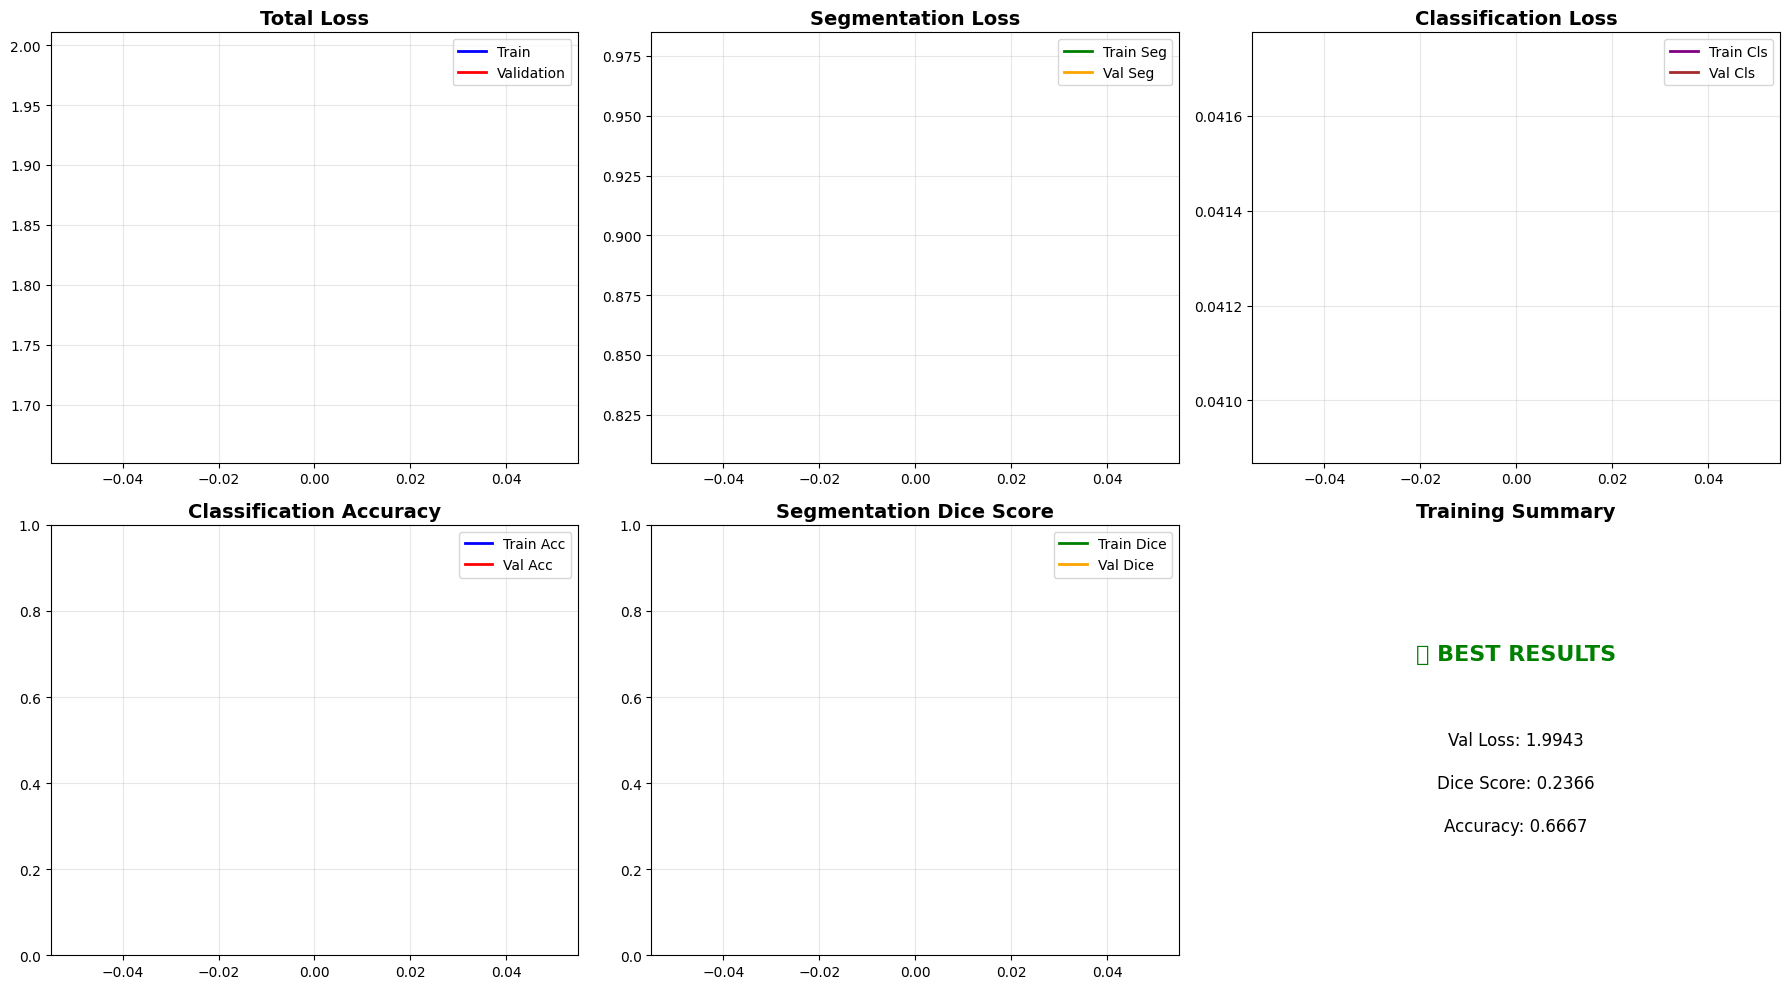


🔄 EPOCH 2/30
------------------------------------------------------------


✅ Validation Epoch 2: 100%|███████████████████████████████████████████████████████████| 4/4 [00:02]



📊 EPOCH 2 RESULTS:
   🔥 TRAIN   → Loss: 1.2691 | Acc: 0.6714 | Dice: 0.6230
   ✅ VAL     → Loss: 1.3468 | Acc: 0.6667 | Dice: 0.6252
   📈 LR: 9.05e-05 | F1: 0.8000 | AUC: 0.5000


KeyboardInterrupt: 

In [ ]:
# Start training
results = train_fundus_model(
    pipeline=pipeline,     # Cell 1 से आपका pipeline
    num_epochs=30,         # Training epochs
    batch_size=4,          # GPU memory के हिसाब से adjust करें
    learning_rate=1e-4     # Learning rate
)